In [10]:
import ccxt
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
params = {
    'token': 'RIVER',
    'exchange': 'binance',
    'date_start': datetime.now() - timedelta(days=7),
    'date_end': datetime.now(),
}

In [14]:
data = pd.DataFrame()
exchange = getattr(ccxt, params['exchange'])()
ticker_symbol = f"{params['token']}USDT"

date_start = params['date_start']
date_end = params['date_end']
if date_end <= date_start:
    date_end = datetime.now()

since = int(date_start.timestamp() * 1000)
end_ms = int(date_end.timestamp() * 1000)

all_tickers = []
while since < end_ms:
    try:
        batch = exchange.fetch_funding_rate_history(
            symbol=ticker_symbol,
            since=since,
            limit=1000  # 8*1000 = 8000 hours ~ 333 days
        )
    except Exception as e:
        print(f"fetch_funding_rate_history failed: {e}")
        break

    if not batch:
        break

    all_tickers.extend(batch)
    last_ts = batch[-1].get("timestamp")
    if last_ts is None:
        break
    since = last_ts + 1

tickers = all_tickers

if tickers:
    data = pd.DataFrame(tickers)
data

,info,symbol,fundingRate,timestamp,datetime
0,"{'symbol': 'RIVERUSDT', 'fundingTime': '176938...",RIVER/USDT:USDT,-0.001242,1769385600000,2026-01-26T00:00:00.000Z
1,"{'symbol': 'RIVERUSDT', 'fundingTime': '176940...",RIVER/USDT:USDT,-0.001994,1769400000000,2026-01-26T04:00:00.000Z
2,"{'symbol': 'RIVERUSDT', 'fundingTime': '176941...",RIVER/USDT:USDT,-0.004210,1769414400003,2026-01-26T08:00:00.003Z
3,"{'symbol': 'RIVERUSDT', 'fundingTime': '176942...",RIVER/USDT:USDT,-0.015937,1769428800000,2026-01-26T12:00:00.000Z
4,"{'symbol': 'RIVERUSDT', 'fundingTime': '176944...",RIVER/USDT:USDT,-0.020000,1769443200000,2026-01-26T16:00:00.000Z
...,...,...,...,...,...
148,"{'symbol': 'RIVERUSDT', 'fundingTime': '176996...",RIVER/USDT:USDT,0.000281,1769961600000,2026-02-01T16:00:00.000Z
149,"{'symbol': 'RIVERUSDT', 'fundingTime': '176996...",RIVER/USDT:USDT,0.000101,1769965200002,2026-02-01T17:00:00.002Z
150,"{'symbol': 'RIVERUSDT', 'fundingTime': '176996...",RIVER/USDT:USDT,0.000115,1769968800000,2026-02-01T18:00:00.000Z
151,"{'symbol': 'RIVERUSDT', 'fundingTime': '176997...",RIVER/USDT:USDT,-0.000001,1769972400014,2026-02-01T19:00:00.014Z


  SYMBOL : 0G | paradex long / orderly short
  Position size :   $1000.00
  Exec cost :       $2.00  (10 bps x2)
  Average APR :     220.18%
---------------------------------------------
  Total PnL (brut): $42.23
  Total PnL (net):  $40.23  (4.02%)
  Final Value :     $1040.23
  Max Drawdown :    $-2.71  (-0.27%)
  Sharpe Ratio :    53.42


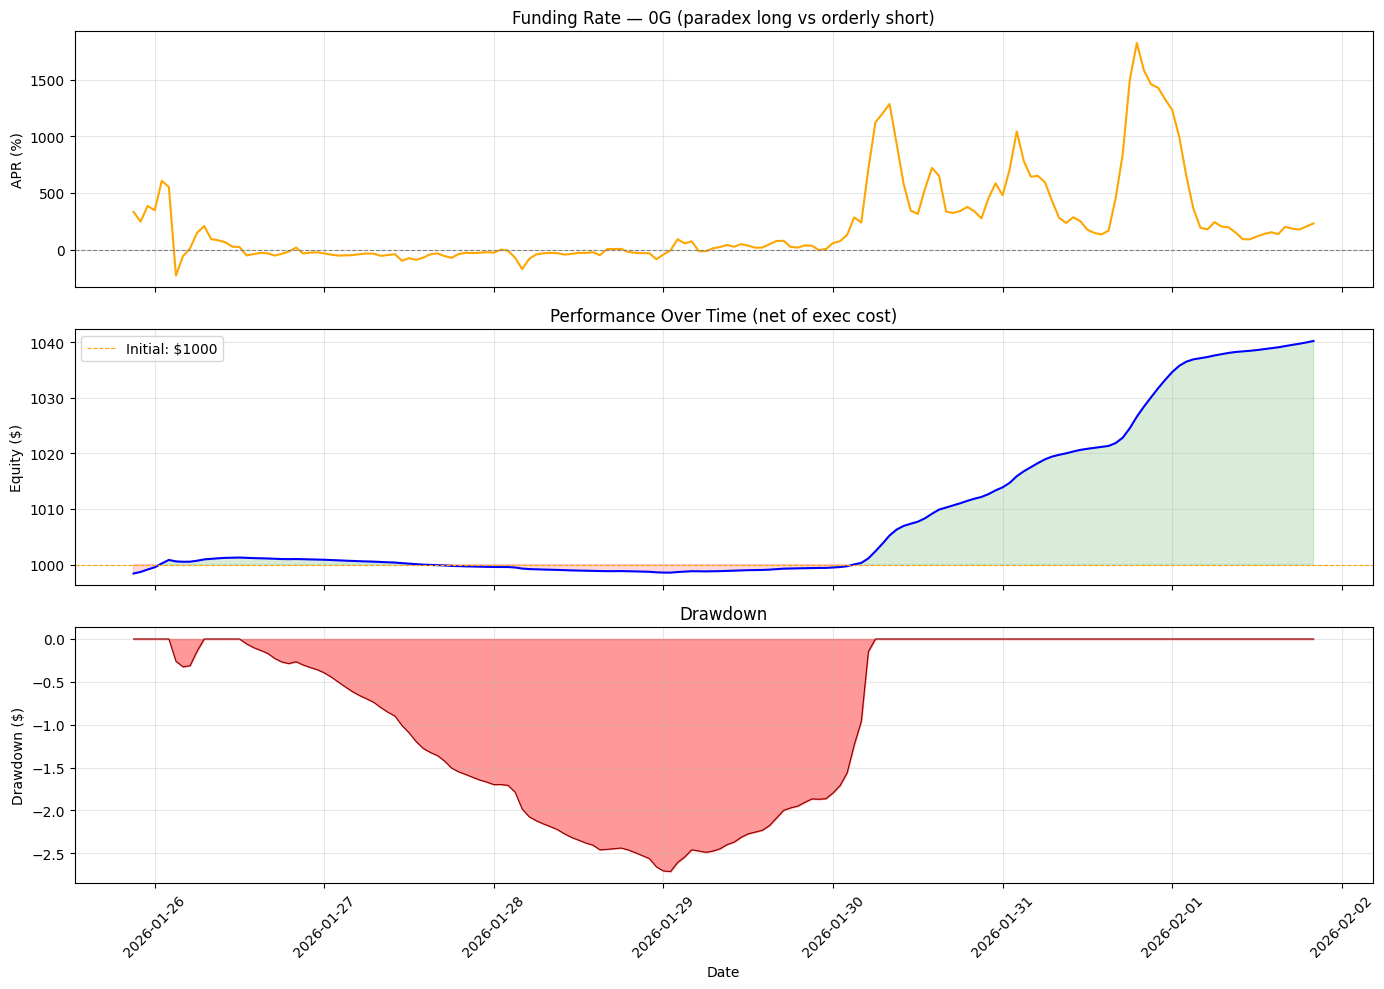

In [19]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta, timezone

# --- Configuration ---
symbol = '0G'
long_exchange = 'paradex'
short_exchange = 'orderly'
duration = '7d'        # '1d', '7d', '30d', '90d', '180d', '365d', 'all'
position_size = 1000       # $ investis
exec_cost_bps = 10         # bps (ex: 10 bps = 0.10%)

url = (
    f"https://fundingview.app/api/history"
    f"?symbol={symbol}&long={long_exchange}"
    f"&short={short_exchange}&duration={duration}"
)

try:
    response = requests.get(url)
    response.raise_for_status()
    api_data = response.json()

    points = api_data.get('points', {})
    df = pd.DataFrame({
        'timestamp': points.get('t', []),
        'funding_rate': points.get('apr', [])
    })

    if df.empty:
        raise ValueError("Aucune donnée reçue de l'API.")

    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', utc=True)
    df.set_index('timestamp', inplace=True)
    df = df[df.index >= pd.Timestamp.now(tz=timezone.utc) - pd.Timedelta(duration)]
    df.sort_index(inplace=True)

    # --- Execution cost (aller + retour = x2) ---
    exec_cost = position_size * (exec_cost_bps / 10000) * 2  # en $

    # --- Calcul des retours horaires ---
    # APR = taux annuel -> retour horaire = APR / 100 / 8760
    df['returns'] = df['funding_rate'] / 100 / 8760
    df['cumulative_returns'] = df['returns'].cumsum()

    # --- PnL en $ ---
    df['equity'] = position_size * (1 + df['cumulative_returns'])
    # On applique l'exec cost une seule fois au début
    df['equity_net'] = df['equity'] - exec_cost

    # --- Statistiques ---
    total_pnl_gross = (df['cumulative_returns'].iloc[-1]) * position_size
    total_pnl_net = total_pnl_gross - exec_cost
    avg_apr = df['funding_rate'].mean()

    rolling_max = df['equity_net'].cummax()
    drawdown = df['equity_net'] - rolling_max
    max_drawdown = drawdown.min()  # négatif
    max_drawdown_pct = (max_drawdown / position_size) * 100

    sharpe_ratio = (df['returns'].mean() / df['returns'].std()) * np.sqrt(8760)

    print("=" * 45)
    print(f"  SYMBOL : {symbol} | {long_exchange} long / {short_exchange} short")
    print("=" * 45)
    print(f"  Position size :   ${position_size:.2f}")
    print(f"  Exec cost :       ${exec_cost:.2f}  ({exec_cost_bps} bps x2)")
    print(f"  Average APR :     {avg_apr:.2f}%")
    print("-" * 45)
    print(f"  Total PnL (brut): ${total_pnl_gross:.2f}")
    print(f"  Total PnL (net):  ${total_pnl_net:.2f}  ({total_pnl_net/position_size*100:.2f}%)")
    print(f"  Final Value :     ${position_size + total_pnl_net:.2f}")
    print(f"  Max Drawdown :    ${max_drawdown:.2f}  ({max_drawdown_pct:.2f}%)")
    print(f"  Sharpe Ratio :    {sharpe_ratio:.2f}")
    print("=" * 45)

    # --- Plot 1 : Funding Rate (APR) ---
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(df.index, df['funding_rate'], color='orange', linewidth=1.5)
    axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    axes[0].set_ylabel('APR (%)')
    axes[0].set_title(f'Funding Rate — {symbol} ({long_exchange} long vs {short_exchange} short)')
    axes[0].grid(True, alpha=0.3)

    # --- Plot 2 : Equity curve (net) ---
    axes[1].plot(df.index, df['equity_net'], color='blue', linewidth=1.5)
    axes[1].axhline(y=position_size, color='orange', linestyle='--', linewidth=0.8, label=f'Initial: ${position_size}')
    axes[1].fill_between(df.index, position_size, df['equity_net'],
                         where=(df['equity_net'] >= position_size),
                         color='green', alpha=0.15)
    axes[1].fill_between(df.index, position_size, df['equity_net'],
                         where=(df['equity_net'] < position_size),
                         color='red', alpha=0.15)
    axes[1].set_ylabel('Equity ($)')
    axes[1].set_title('Performance Over Time (net of exec cost)')
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.3)

    # --- Plot 3 : Drawdown ---
    axes[2].fill_between(df.index, drawdown, 0, color='red', alpha=0.4)
    axes[2].plot(df.index, drawdown, color='darkred', linewidth=0.8)
    axes[2].set_ylabel('Drawdown ($)')
    axes[2].set_xlabel('Date')
    axes[2].set_title('Drawdown')
    axes[2].grid(True, alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

except requests.exceptions.RequestException as e:
    print(f"Erreur réseau / API : {e}")
except ValueError as e:
    print(f"Erreur de données : {e}")
except Exception as e:
    print(f"Erreur inattendue : {e}")